# Error-driven Payoff and Fairness

In [7]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from Utils.interaction import Performer
from Classes.cognitive_model_agents import FairnessM1, AttendanceM1

(-0.05, 1.05)

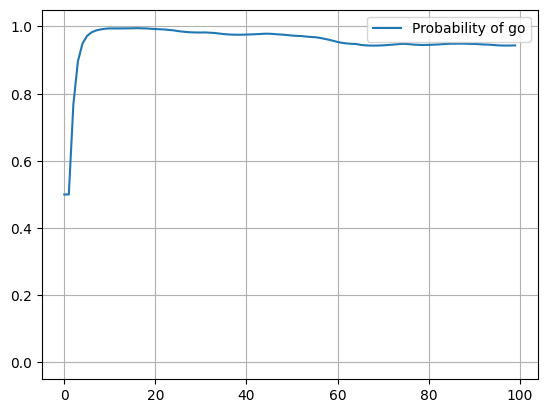

In [8]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate":0.2,
	"bias":0.75,
    "individual_threshold":0.5,
	"inverse_temperature":16,
}
agent = FairnessM1(
    free_parameters=free_parameters,
    fixed_parameters=fixed_parameters,
)
agent.number = 0

agent.debug = False

probabilities = []
powers = []
rng = np.random.default_rng()
num_rounds = 100
p = 0.25

actions = rng.choice([0, 1], size=num_rounds, p=[1 - p, p])

for i, action in enumerate(actions):
    obs_state = [action] + [1] * (fixed_parameters['num_agents'] - 1)
    payoff = agent.payoff(action, obs_state)
    power_ = agent._get_G(obs_state)
    prob = agent.go_probability()
    probabilities.append(prob)
    powers.append(power_)
    if agent.debug:
        print("")
        print("="*60)
    agent.update(payoff, obs_state)

ax = sns.lineplot(
    x=range(len(probabilities)), y=probabilities, label="Probability of go"
)
# sns.lineplot(
#     x=range(len(powers)), y=powers, ax=ax, label="Preference"
# )
ax.grid()
ax.set_ylim(-0.05, 1.05)

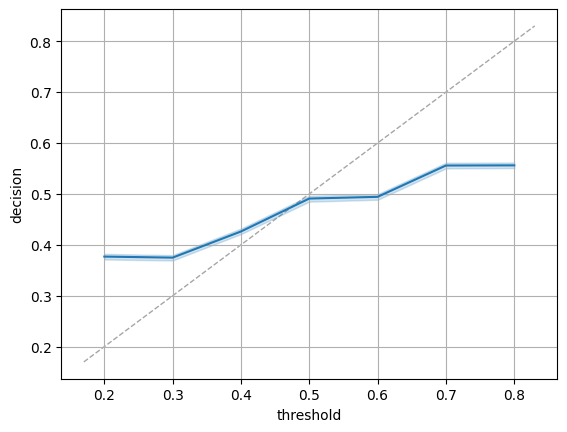

In [9]:
simulation_parameters = {
	'num_episodes':50,
	'num_rounds':100,
	'verbose':False
}

df_list = []
list_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in list_thresholds:
    fixed_parameters['threshold'] = threshold
    df = Performer.sim(
        agent_class=FairnessM1,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters,
    )
    df['threshold'] = threshold
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

ax = sns.lineplot(
    x='threshold', y='decision',
    data=df,
)
ax.grid()
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
lo, hi = min(x0, y0), max(x1, y1)
ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
